
# Studi Kasus Klasifikasi Menggunakan ANN/JST
## Dataset: Heart Disease Dataset (Kaggle)

Dataset yang digunakan berasal dari Kaggle:

Heart Disease Dataset Kaggle_https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## Tujuan
Melakukan klasifikasi untuk memprediksi apakah seseorang memiliki penyakit jantung atau tidak menggunakan metode Artificial Neural Network (ANN).



# 1. Import Library
Library digunakan untuk:
- Mengolah data
- Membuat model ANN
- Evaluasi model


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



# 2. Load Dataset

Upload file dataset `heart.csv` ke Google Colab terlebih dahulu.


In [2]:

df = pd.read_csv('heart.csv')

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



# 3. Informasi Dataset
Melihat jumlah data dan struktur dataset.


In [3]:

print(df.info())
print("\nJumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Jumlah data: 1025
Jumlah kolom: 14



# 4. Menentukan Fitur dan Target

Target:
- 1 = Memiliki penyakit jantung
- 0 = Tidak memiliki penyakit jantung


In [4]:

X = df.drop('target', axis=1)
y = df['target']



# 5. Normalisasi Data
Normalisasi dilakukan agar performa ANN lebih baik.


In [5]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



# 6. Split Data Training dan Testing
Data dibagi:
- 80% training
- 20% testing


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Data training:", X_train.shape[0])
print("Data testing:", X_test.shape[0])


Data training: 820
Data testing: 205



# 7. Membuat Model ANN/JST
Arsitektur:
- Hidden layer 1 = 16 neuron
- Hidden layer 2 = 8 neuron
- Output layer = 1 neuron


In [7]:

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)


# 8. Compile dan Training Model


In [8]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5823 - loss: 0.7212 - val_accuracy: 0.6098 - val_loss: 0.6753
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6799 - loss: 0.6169 - val_accuracy: 0.6951 - val_loss: 0.6123
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7439 - loss: 0.5323 - val_accuracy: 0.7500 - val_loss: 0.5584
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8034 - loss: 0.4550 - val_accuracy: 0.7561 - val_loss: 0.5220
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8338 - loss: 0.3974 - val_accuracy: 0.7683 - val_loss: 0.5041
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8613 - loss: 0.3575 - val_accuracy: 0.7744 - val_loss: 0.4936
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8674 - loss: 0.3298 - val_accuracy: 0.7866 - val_loss: 0.4872
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8643 - loss: 0.3123 - val_accuracy: 0.7744 - val_loss:


# 9. Visualisasi Accuracy


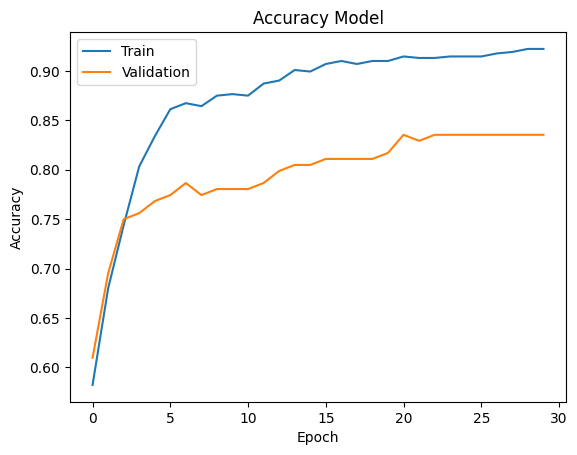

In [9]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()



# 10. Evaluasi Model


In [10]:

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8488 - loss: 0.3583 
Accuracy: 0.8487805128097534



# 11. Prediksi Data


In [11]:

prediksi = model.predict(X_test)

prediksi = (prediksi > 0.5).astype(int)

print(prediksi[:10])


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[[1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]]



# 12. Classification Report


In [12]:

print(classification_report(y_test, prediksi))


              precision    recall  f1-score   support

           0       0.88      0.80      0.84       102
           1       0.82      0.89      0.86       103

    accuracy                           0.85       205
   macro avg       0.85      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205




# Analisis

Model ANN berhasil digunakan untuk klasifikasi penyakit jantung.

Data diproses menggunakan normalisasi dan dibagi menjadi data training serta testing.

Hasil accuracy menunjukkan bahwa metode ANN mampu mempelajari pola data dengan cukup baik untuk membedakan pasien yang memiliki penyakit jantung dan yang tidak.

Semakin banyak epoch dan kualitas preprocessing data, maka performa model dapat meningkat.



# Kesimpulan

Artificial Neural Network (ANN) dapat digunakan untuk menyelesaikan permasalahan klasifikasi pada dataset penyakit jantung.

Model mampu melakukan prediksi dengan baik dan menghasilkan accuracy yang cukup tinggi.
